In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv("../data/train_3.csv")
validation = pd.read_csv("../data/validation_3.csv")
test = pd.read_csv("../data/test_3.csv")

print("Train     :", train.shape)
print("Validation:", validation.shape)
print("Test      :", test.shape)

Train     : (67533, 83)
Validation: (14471, 83)
Test      : (14472, 83)


In [2]:
missing = pd.DataFrame({
    "missing": train.isna().sum(),
    "missing_%": train.isna().mean().mul(100).round(2),
    "dtype": train.dtypes
})

display(missing[missing["missing"] > 0].sort_values("missing", ascending=False))

,missing,missing_%,dtype
mean_product_photos,1197,1.77,float64
review_count,515,0.76,float64
review_creation_median,515,0.76,str
review_answer_median,515,0.76,str
review_answer_min,515,0.76,str
review_answer_max,515,0.76,str
review_creation_min,515,0.76,str
review_creation_max,515,0.76,str
mean_seller_distance_km,344,0.51,float64
median_seller_distance_km,344,0.51,float64


In [3]:
missing_by_target = []

for col in train.columns:

    missing_0 = train.loc[train["delayed"] == 0, col].isna().mean() * 100
    missing_1 = train.loc[train["delayed"] == 1, col].isna().mean() * 100

    total_missing = train[col].isna().sum()

    if total_missing > 0:
        missing_by_target.append({
            "feature": col,
            "total_missing": total_missing,
            "overall_missing_%": train[col].isna().mean() * 100,
            "missing_%_not_delayed": missing_0,
            "missing_%_delayed": missing_1,
            "difference_pp": missing_1 - missing_0
        })

missing_target = pd.DataFrame(missing_by_target)

missing_target = (
    missing_target
    .sort_values("difference_pp", ascending=False)
    .reset_index(drop=True)
)

missing_target.round(2)

,feature,total_missing,overall_missing_%,missing_%_not_delayed,missing_%_delayed,difference_pp
0,review_count,515,0.76,0.62,2.25,1.63
1,review_answer_max,515,0.76,0.62,2.25,1.63
2,review_creation_min,515,0.76,0.62,2.25,1.63
3,review_creation_median,515,0.76,0.62,2.25,1.63
4,review_answer_min,515,0.76,0.62,2.25,1.63
5,review_answer_median,515,0.76,0.62,2.25,1.63
6,review_creation_max,515,0.76,0.62,2.25,1.63
7,customer_lat,181,0.27,0.26,0.39,0.14
8,customer_lng,181,0.27,0.26,0.39,0.14
9,median_seller_distance_km,344,0.51,0.50,0.62,0.13


## delete columns

In [4]:
# ============================================================
# REMOVE UNWANTED / LEAKAGE FEATURES FROM ALL SPLITS
# ============================================================

DROP_COLS = [

    # IDs
    "order_id",
    "customer_id",

    # Review features — leakage
    "review_count",
    "review_creation_min",
    "review_creation_max",
    "review_creation_median",
    "review_answer_min",
    "review_answer_max",
    "review_answer_median",

    # Price
    "min_price",
    "max_price",
    "mean_price",
    "median_price",

    # Freight
    "total_freight",
    "max_freight",
    "mean_freight",
    "median_freight",

    # Weight
    "total_weight_g",
    "max_weight_g",
    "mean_weight_g",
    "median_weight_g",

    # Volume
    "total_volume_cm3",
    "max_volume_cm3",
    "mean_volume_cm3",
    "median_volume_cm3",

    # Product photos
    "total_product_photos",
    "mean_product_photos",

    # Payment
    "payment_count",
    "min_payment",
    "max_payment",
    "mean_payment",
    "median_payment",
    "payment_type_boleto",
    "payment_type_credit_card",
    "payment_type_debit_card",
    "payment_type_not_defined",
    "payment_type_voucher",

    # Purchase time
    "purchase_time_max",
    "purchase_time_median",

    # Approval time
    "approval_time_max",
    "approval_time_median",

    # Carrier date — unavailable at prediction time
    "carrier_date_min",
    "carrier_date_max",
    "carrier_date_median",

    # Delivery date — leakage
    "delivered_date_min",
    "delivered_date_max",
    "delivered_date_median",

    # Seller states
    # "unique_seller_states",

    # Seller coordinates
    "seller_lat",
    "seller_lng",
    "year",

    # Seller distance
    "max_seller_distance_km",
    "mean_seller_distance_km",
    "median_seller_distance_km",

    # Order status — not used as a prediction feature
    "order_status",

    # Estimated delivery dates
    "estimated_delivery_date_min",
    "estimated_delivery_date_max",
    "estimated_delivery_date_median",

    # Shipping limit — not used as a prediction feature
    "shipping_limit_min",
    "shipping_limit_max",
    "shipping_limit_median",

    # Targets
    # "delay_days",
    # "delayed"
]


# ============================================================
# APPLY TO TRAIN / VALIDATION / TEST
# ============================================================

train_clean = train.drop(
    columns=DROP_COLS,
    errors="ignore"
).copy()

validation_clean = validation.drop(
    columns=DROP_COLS,
    errors="ignore"
).copy()

test_clean = test.drop(
    columns=DROP_COLS,
    errors="ignore"
).copy()


# ============================================================
# CHECK SHAPES
# ============================================================

print("=" * 70)
print("SHAPES AFTER COLUMN REMOVAL")
print("=" * 70)

print("Train     :", train_clean.shape)
print("Validation:", validation_clean.shape)
print("Test      :", test_clean.shape)


# ============================================================
# CHECK THAT ALL THREE HAVE THE SAME FEATURES
# ============================================================

print("\n" + "=" * 70)
print("FEATURE CONSISTENCY")
print("=" * 70)

print(
    "Train == Validation:",
    train_clean.columns.tolist() == validation_clean.columns.tolist()
)

print(
    "Train == Test:",
    train_clean.columns.tolist() == test_clean.columns.tolist()
)


# ============================================================
# REMAINING COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("REMAINING COLUMNS")
print("=" * 70)

print(train_clean.columns.tolist())

SHAPES AFTER COLUMN REMOVAL
Train     : (67533, 23)
Validation: (14471, 23)
Test      : (14472, 23)

FEATURE CONSISTENCY
Train == Validation: True
Train == Test: True

REMAINING COLUMNS
['customer_zip_code_prefix', 'customer_state', 'customer_lat', 'customer_lng', 'purchase_time_min', 'approval_time_min', 'customer_city', 'item_count', 'unique_products', 'seller_count', 'total_price', 'min_freight', 'unique_seller_states', 'seller_city', 'sellers_same_customer_state', 'unique_category_count', 'min_weight_g', 'min_volume_cm3', 'min_seller_distance_km', 'total_payment', 'max_installments', 'delay_days', 'delayed']


## create

In [5]:
# ============================================================
# PURCHASE FEATURES
# ============================================================

for df in [train_clean, validation_clean, test_clean]:

    df["purchase_time_min"] = pd.to_datetime(df["purchase_time_min"],errors="coerce")
    df["purchase_year"] = df["purchase_time_min"].dt.year
    df["purchase_month"] = df["purchase_time_min"].dt.month
    df["purchase_weekday"] = df["purchase_time_min"].dt.weekday
    df["purchase_hour"] = df["purchase_time_min"].dt.hour
    df["purchase_quarter"] = df["purchase_time_min"].dt.quarter


# ============================================================
# APPROVAL FEATURES
# ============================================================

for df in [train_clean, validation_clean, test_clean]:

    df["approval_time_min"] = pd.to_datetime(df["approval_time_min"],errors="coerce")
    df["approval_year"] = df["approval_time_min"].dt.year
    df["approval_quarter"] = df["approval_time_min"].dt.quarter
    df["approval_month"] = df["approval_time_min"].dt.month
    df["approval_weekday"] = df["approval_time_min"].dt.weekday
    df["approval_day"] = df["approval_time_min"].dt.day
    df["approval_hour"] = df["approval_time_min"].dt.hour


# ============================================================
# REMOVE RAW DATETIME COLUMNS
# ============================================================

for df in [train_clean, validation_clean, test_clean]:
    df.drop(columns=["purchase_time_min","approval_time_min"], inplace=True)


# ============================================================
# CHECK
# ============================================================

print("Train     :", train_clean.shape)
print("Validation:", validation_clean.shape)
print("Test      :", test_clean.shape)

Train     : (67533, 32)
Validation: (14471, 32)
Test      : (14472, 32)


## outliers

In [6]:
# # ============================================================
# # VALUE CLEANING
# # ============================================================

# def apply_value_rules(df):
#     df = df.copy()

#     # seller_count: values > 3 -> 3
#     df["seller_count"] = df["seller_count"].clip(upper=3)

#     # item_count: remove 21, values > 6 -> 6
#     df = df[df["item_count"] != 21].copy()
#     df["item_count"] = df["item_count"].clip(upper=6)

#     # unique_products: values > 4 -> 4
#     df["unique_products"] = df["unique_products"].clip(upper=4)

#     # unique_category_count: remove 6
#     df = df[df["unique_category_count"] != 6].copy()

#     # unique_seller_states: remove 3
#     df = df[df["unique_seller_states"] != 3].copy()

#     return df


# # Apply to the already-cleaned datasets
# train_clean = apply_value_rules(train_clean)
# validation_clean = apply_value_rules(validation_clean)
# test_clean = apply_value_rules(test_clean)


# # ============================================================
# # OUTLIERS — TRAIN ONLY
# # Only delayed = 0
# # ============================================================

# OUTLIER_COLS = [
#     "total_price",
#     "min_freight",
#     "min_weight_g"
# ]

# for col in OUTLIER_COLS:

#     q1 = train_clean.loc[
#         train_clean["delayed"] == 0, col
#     ].quantile(0.25)

#     q3 = train_clean.loc[
#         train_clean["delayed"] == 0, col
#     ].quantile(0.75)

#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     outlier_mask = (
#         (train_clean["delayed"] == 0) &
#         (
#             (train_clean[col] < lower) |
#             (train_clean[col] > upper)
#         )
#     )

#     removed = outlier_mask.sum()

#     train_clean = train_clean.loc[~outlier_mask].copy()

#     print(
#         f"{col}: removed {removed} outliers | "
#         f"lower = {lower:.2f}, upper = {upper:.2f}"
#     )


# # ============================================================
# # RESULTS
# # ============================================================

# print("\n" + "=" * 60)
# print("SHAPES AFTER VALUE CLEANING + OUTLIERS")
# print("=" * 60)

# print("Train     :", train_clean.shape)
# print("Validation:", validation_clean.shape)
# print("Test      :", test_clean.shape)

In [7]:
# ============================================================
# VALUE CLEANING
# ============================================================

def apply_value_rules(df):
    df = df.copy()

    # seller_count: values > 3 -> 3
    df["seller_count"] = df["seller_count"].clip(upper=3)

    # item_count: remove 21, values > 6 -> 6
    df = df[df["item_count"] != 21].copy()
    df["item_count"] = df["item_count"].clip(upper=6)

    # unique_products: values > 4 -> 4
    df["unique_products"] = df["unique_products"].clip(upper=4)

    # unique_category_count: remove 6
    df = df[df["unique_category_count"] != 6].copy()

    # unique_seller_states: remove 3
    df = df[df["unique_seller_states"] != 3].copy()

    # delay_days: values > 70 -> 70
    df["delay_days"] = df["delay_days"].clip(upper=70)

    return df


# Apply to the datasets
train_clean = apply_value_rules(train_clean)
validation_clean = apply_value_rules(validation_clean)
test_clean = apply_value_rules(test_clean)


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("SHAPES AFTER VALUE CLEANING")
print("=" * 60)

print("Train     :", train_clean.shape)
print("Validation:", validation_clean.shape)
print("Test      :", test_clean.shape)

print("\nMaximum delay_days:")
print("Train     :", train_clean["delay_days"].max())
print("Validation:", validation_clean["delay_days"].max())
print("Test      :", test_clean["delay_days"].max())


SHAPES AFTER VALUE CLEANING
Train     : (67527, 32)
Validation: (14470, 32)
Test      : (14471, 32)

Maximum delay_days:
Train     : 70.0
Validation: 70.0
Test      : 60.61303240740741


## missing

In [8]:
# ============================================================
# MISSING VALUES CHECK
# ============================================================

for name, df in [
    ("TRAIN", train_clean),
    ("VALIDATION", validation_clean),
    ("TEST", test_clean)
]:

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_%": df.isna().mean() * 100
    })

    missing = (
        missing[missing["missing_count"] > 0]
        .sort_values("missing_count", ascending=False)
    )

    if missing.empty:
        print("No missing values.")
    else:
        print(missing.round(2))


TRAIN
                        missing_count  missing_%
min_seller_distance_km            344       0.51
customer_lat                      181       0.27
customer_lng                      181       0.27
min_weight_g                       16       0.02
min_volume_cm3                     16       0.02
approval_quarter                   14       0.02
approval_year                      14       0.02
approval_weekday                   14       0.02
approval_month                     14       0.02
approval_day                       14       0.02
approval_hour                      14       0.02
total_payment                       1       0.00
max_installments                    1       0.00

VALIDATION
                        missing_count  missing_%
min_seller_distance_km             74       0.51
customer_lat                       40       0.28
customer_lng                       40       0.28

TEST
                        missing_count  missing_%
min_seller_distance_km             58       

In [9]:
# ============================================================
# MISSING VALUE IMPUTATION
# Median values are learned from TRAIN only
# ============================================================

# Columns that contain missing values
IMPUTE_COLS = [
    "min_seller_distance_km",
    "customer_lat",
    "customer_lng",
    "min_weight_g",
    "min_volume_cm3",
    "approval_year",
    "approval_quarter",
    "approval_weekday",
    "approval_month",
    "approval_day",
    "approval_hour",
    "total_payment",
    "max_installments"
]


# ============================================================
# 1. CALCULATE MEDIANS FROM TRAIN ONLY
# ============================================================

train_medians = train_clean[IMPUTE_COLS].median()


print("=" * 70)
print("MEDIAN VALUES LEARNED FROM TRAIN")
print("=" * 70)

print(train_medians)


# ============================================================
# 2. APPLY TRAIN MEDIANS TO ALL THREE DATASETS
# ============================================================

train_clean[IMPUTE_COLS] = train_clean[IMPUTE_COLS].fillna(
    train_medians
)

validation_clean[IMPUTE_COLS] = validation_clean[IMPUTE_COLS].fillna(
    train_medians
)

test_clean[IMPUTE_COLS] = test_clean[IMPUTE_COLS].fillna(
    train_medians
)


# ============================================================
# 3. VERIFY REMAINING MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES AFTER IMPUTATION")
print("=" * 70)

for name, df in [
    ("TRAIN", train_clean),
    ("VALIDATION", validation_clean),
    ("TEST", test_clean)
]:

    total_missing = df.isna().sum().sum()

    print(f"{name:<12}: {total_missing} missing values")


# ============================================================
# 4. DETAILED CHECK
# ============================================================

print("\n" + "=" * 70)
print("REMAINING MISSING COLUMNS")
print("=" * 70)

for name, df in [
    ("TRAIN", train_clean),
    ("VALIDATION", validation_clean),
    ("TEST", test_clean)
]:

    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{name}")

    if missing.empty:
        print("No missing values.")
    else:
        print(missing)

MEDIAN VALUES LEARNED FROM TRAIN
min_seller_distance_km     447.196138
customer_lat               -22.915533
customer_lng               -46.627220
min_weight_g               700.000000
min_volume_cm3            6750.000000
approval_year             2017.000000
approval_quarter             2.000000
approval_weekday             3.000000
approval_month               5.000000
approval_day                15.000000
approval_hour               13.000000
total_payment              104.175000
max_installments             2.000000
dtype: float64

MISSING VALUES AFTER IMPUTATION
TRAIN       : 0 missing values
VALIDATION  : 0 missing values
TEST        : 0 missing values

REMAINING MISSING COLUMNS

TRAIN
No missing values.

VALIDATION
No missing values.

TEST
No missing values.


## GEOGRAPHIC FEATURES → MEAN DELAY ENCODING

In [10]:
# ============================================================
# GEOGRAPHIC FEATURES → MEAN DELAY ENCODING
# Train-only target-derived encoding
# ============================================================

GEO_COLS = [
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "seller_city"
]

geo_mean_delay_maps = {}
global_mean_delay = train_clean["delay_days"].mean()

for col in GEO_COLS:
    mean_delay_map = (
        train_clean
        .groupby(col)["delay_days"]
        .mean()
        .to_dict()
    )

    geo_mean_delay_maps[col] = mean_delay_map
    encoded_col = f"{col}_mean_delay"

    for df in [train_clean, validation_clean, test_clean]:
        df[encoded_col] = df[col].map(mean_delay_map)
        df[encoded_col] = df[encoded_col].fillna(global_mean_delay)

    for df in [train_clean, validation_clean, test_clean]:
        df.drop(columns=[col], inplace=True)

print("=" * 70)
print("MEAN DELAY ENCODING")
print("=" * 70)

for col in GEO_COLS:
    print(f"{col}: {len(geo_mean_delay_maps[col])} categories")

print("\nGlobal fallback mean delay:", global_mean_delay)

MEAN DELAY ENCODING
customer_zip_code_prefix: 13748 categories
customer_city: 3747 categories
customer_state: 27 categories
seller_city: 490 categories

Global fallback mean delay: -10.815269206617765


## encoder 

In [11]:
## one hot for : customer_state
## customer_zip_delay_group    :    Ordinal/Index-like encoding  (0-19)

In [12]:
import pandas as pd
import numpy as np

# ============================================================
# 1. TARGET
# ============================================================

TARGET = "delayed"

y_train = train_clean[TARGET].copy()
y_validation = validation_clean[TARGET].copy()
y_test = test_clean[TARGET].copy()

# ============================================================
# 2. REMOVE TARGETS FROM FEATURES
# ============================================================

X_train = train_clean.drop(columns=["delayed", "delay_days"], errors="ignore").copy()
X_validation = validation_clean.drop(columns=["delayed", "delay_days"], errors="ignore").copy()
X_test = test_clean.drop(columns=["delayed", "delay_days"], errors="ignore").copy()

# ============================================================
# 3. FORCE ALL FEATURES TO NUMERIC
# ============================================================

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_validation = X_validation.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# ============================================================
# 4. CHECK
# ============================================================

print("=" * 70)
print("FINAL FEATURE MATRICES")
print("=" * 70)

print("X_train     :", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test      :", X_test.shape)

print("\nNon-numeric columns:")
print(X_train.select_dtypes(exclude=np.number).columns.tolist())

print("\nRemaining missing values:")
print("Train     :", X_train.isna().sum().sum())
print("Validation:", X_validation.isna().sum().sum())
print("Test      :", X_test.isna().sum().sum())

FINAL FEATURE MATRICES
X_train     : (67527, 30)
X_validation: (14470, 30)
X_test      : (14471, 30)

Non-numeric columns:
[]

Remaining missing values:
Train     : 0
Validation: 0
Test      : 0


/tmp/ipykernel_30/768500702.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


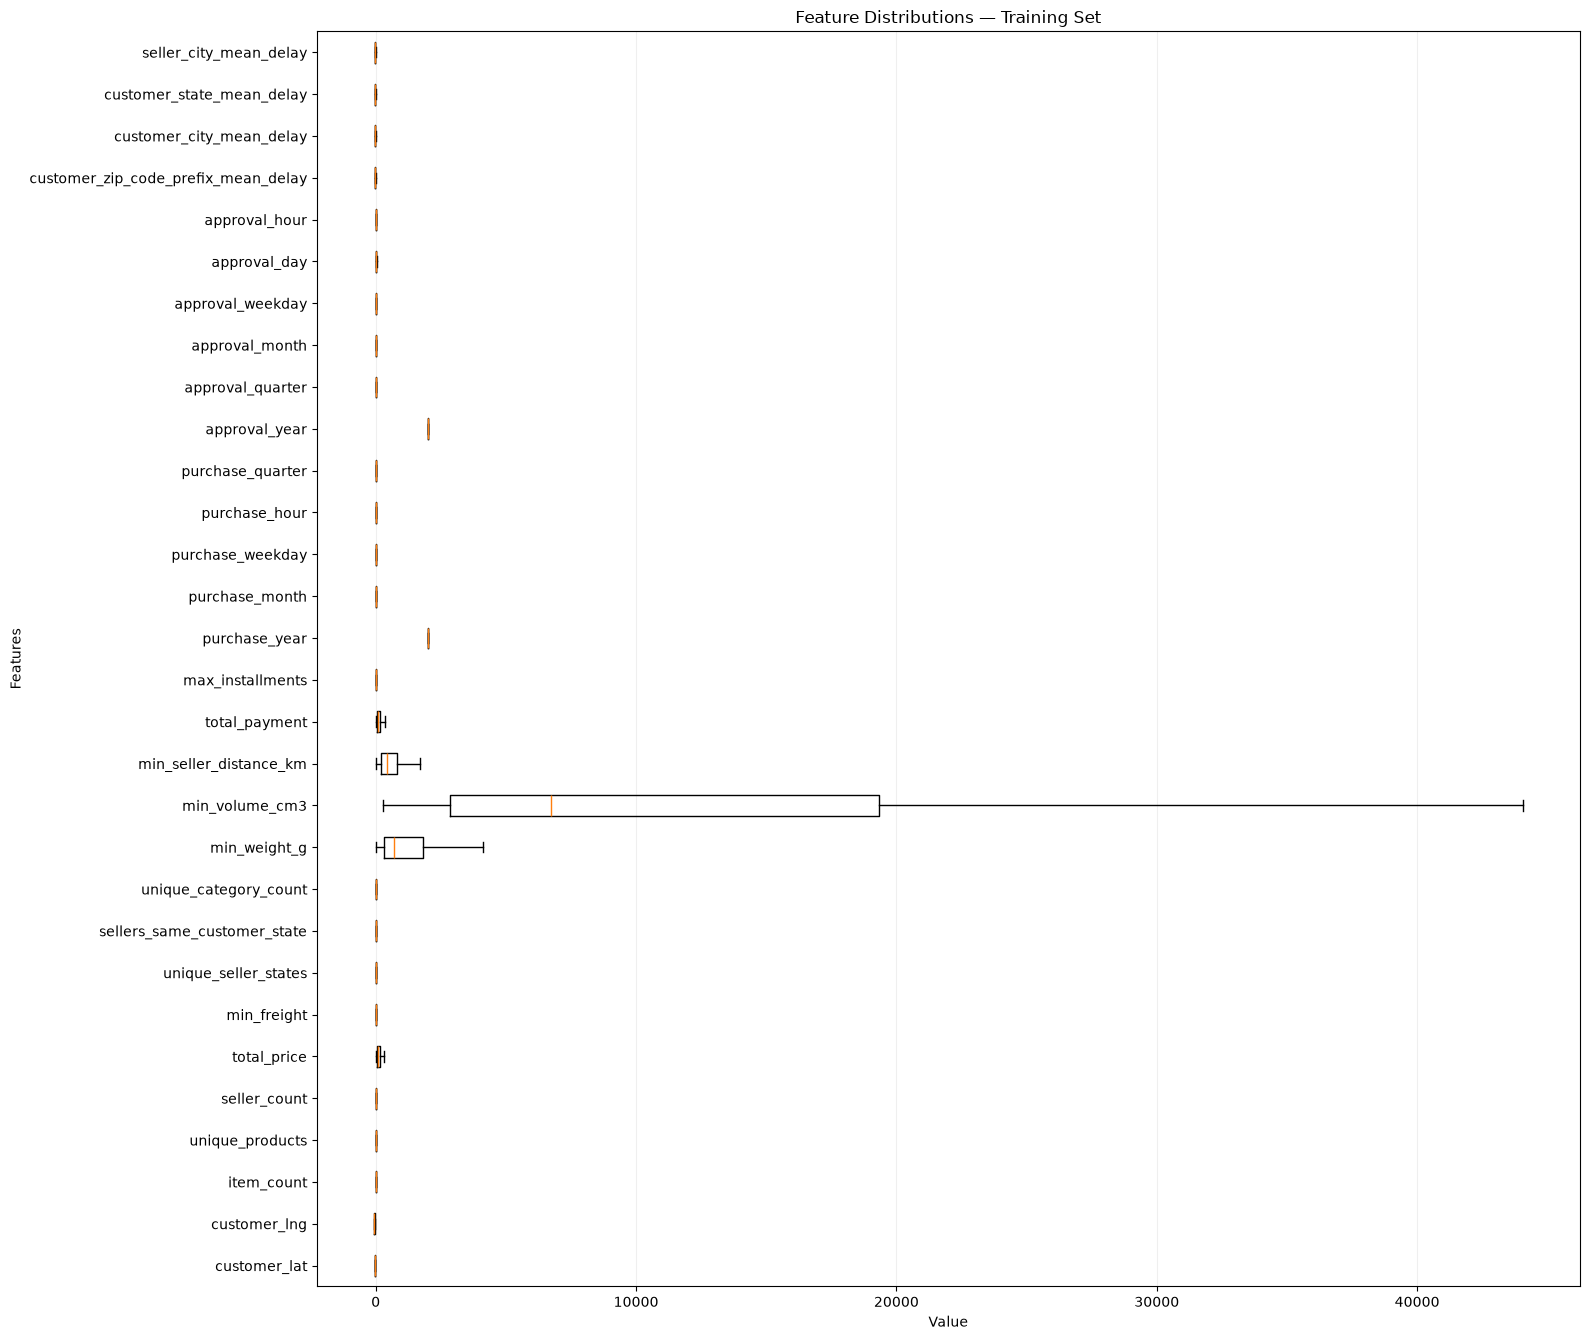

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# HORIZONTAL BOXPLOT — ALL FEATURES
# ============================================================

features = X_train.columns.tolist()

fig, ax = plt.subplots(
    figsize=(16, max(8, len(features) * 0.45))
)

data = [X_train[col].dropna() for col in features]

ax.boxplot(
    data,
    vert=False,
    tick_labels=features,
    showfliers=False
)

ax.set_title("Feature Distributions — Training Set")
ax.set_xlabel("Value")
ax.set_ylabel("Features")

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

## save 1

In [14]:
from pathlib import Path

ARTIFACT_DIR = Path("../artifacts/feature_engineering")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# SAVE RAW FINAL FEATURE TABLES
# ============================================================

X_train.to_csv(ARTIFACT_DIR / "train_features_raw.csv", index=False)
X_validation.to_csv(ARTIFACT_DIR / "validation_features_raw.csv", index=False)
X_test.to_csv(ARTIFACT_DIR / "test_features_raw.csv", index=False)

print("Raw feature tables saved:")
print(ARTIFACT_DIR / "train_features_raw.csv")
print(ARTIFACT_DIR / "validation_features_raw.csv")
print(ARTIFACT_DIR / "test_features_raw.csv")

Raw feature tables saved:
../artifacts/feature_engineering/train_features_raw.csv
../artifacts/feature_engineering/validation_features_raw.csv
../artifacts/feature_engineering/test_features_raw.csv


## min max scaler

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Train     :", X_train_scaled.shape)
print("Validation:", X_validation_scaled.shape)
print("Test      :", X_test_scaled.shape)

print("\nTrain min:", X_train_scaled.min())
print("Train max:", X_train_scaled.max())

Train     : (67527, 30)
Validation: (14470, 30)
Test      : (14471, 30)

Train min: 0.0
Train max: 1.0000000000000002


/tmp/ipykernel_30/1515743261.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


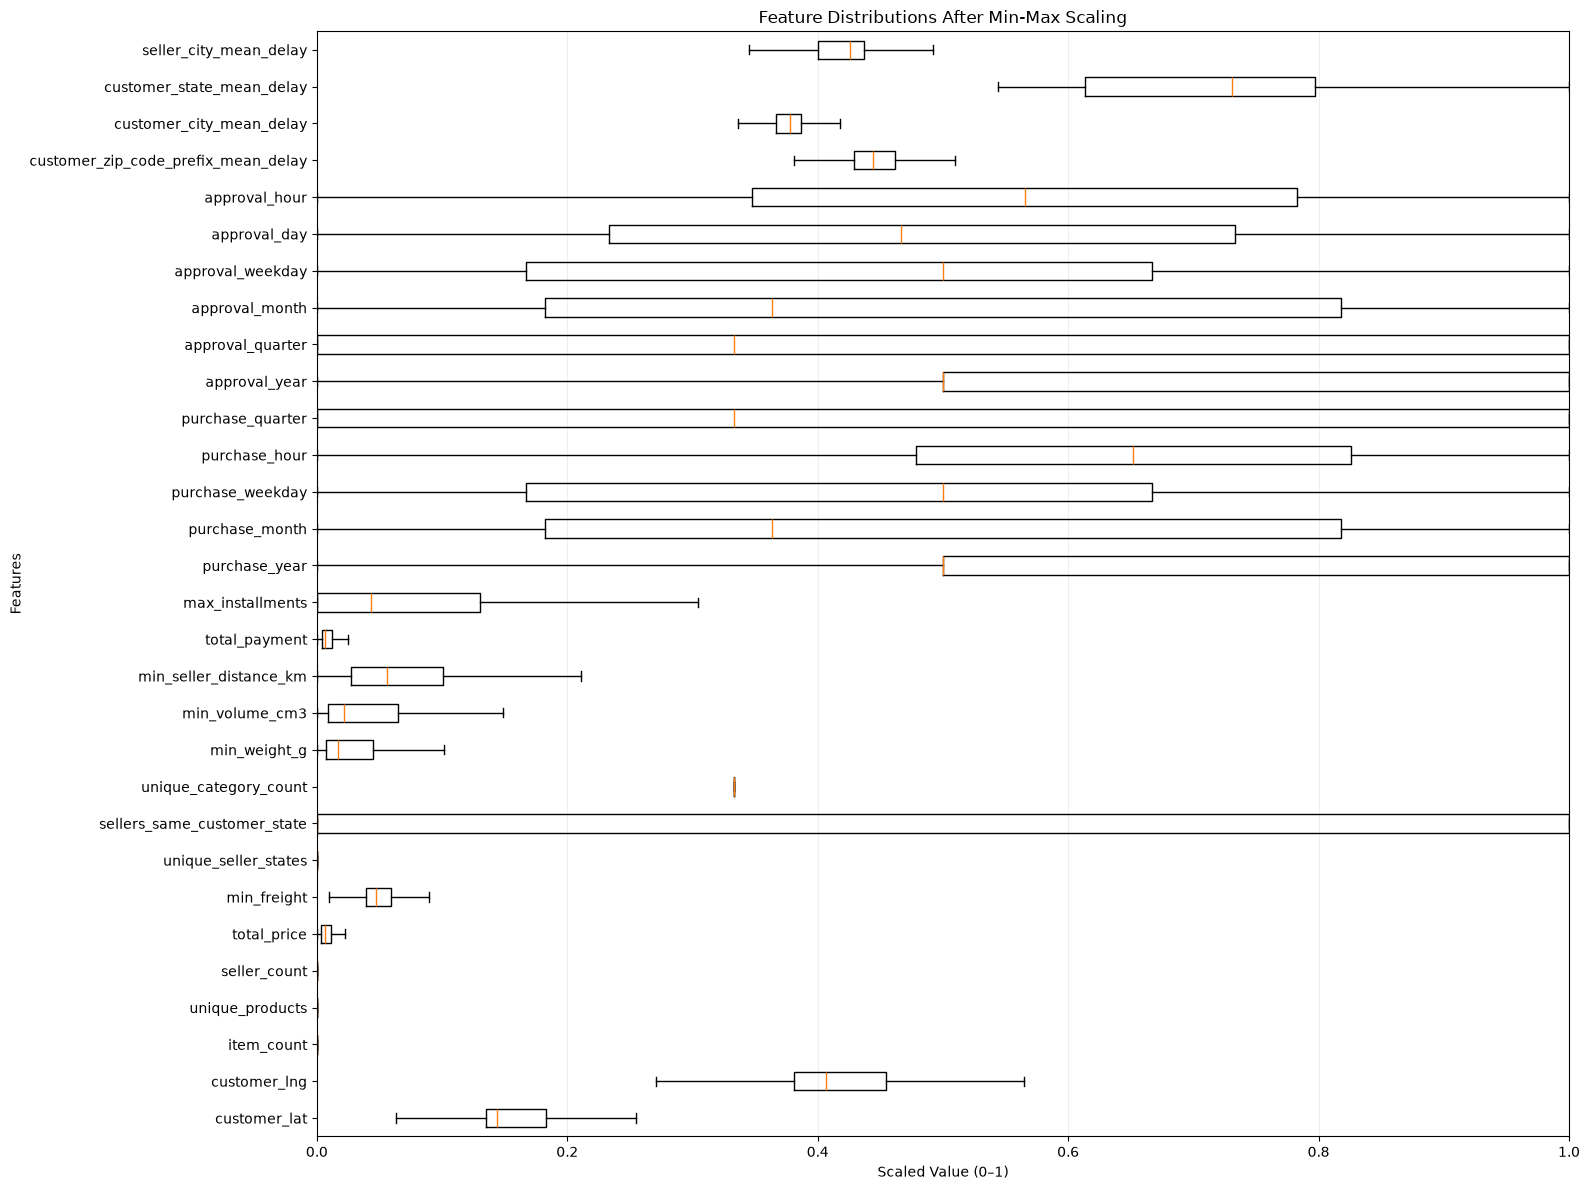

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# HORIZONTAL DISTRIBUTION — ALL SCALED FEATURES
# ============================================================

features = X_train.columns.tolist()

fig, ax = plt.subplots(
    figsize=(16, max(8, len(features) * 0.4))
)

ax.boxplot(
    [X_train_scaled[:, i] for i in range(X_train_scaled.shape[1])],
    vert=False,
    tick_labels=features,
    showfliers=False
)

ax.set_title("Feature Distributions After Min-Max Scaling")
ax.set_xlabel("Scaled Value (0–1)")
ax.set_ylabel("Features")

ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

## correlation

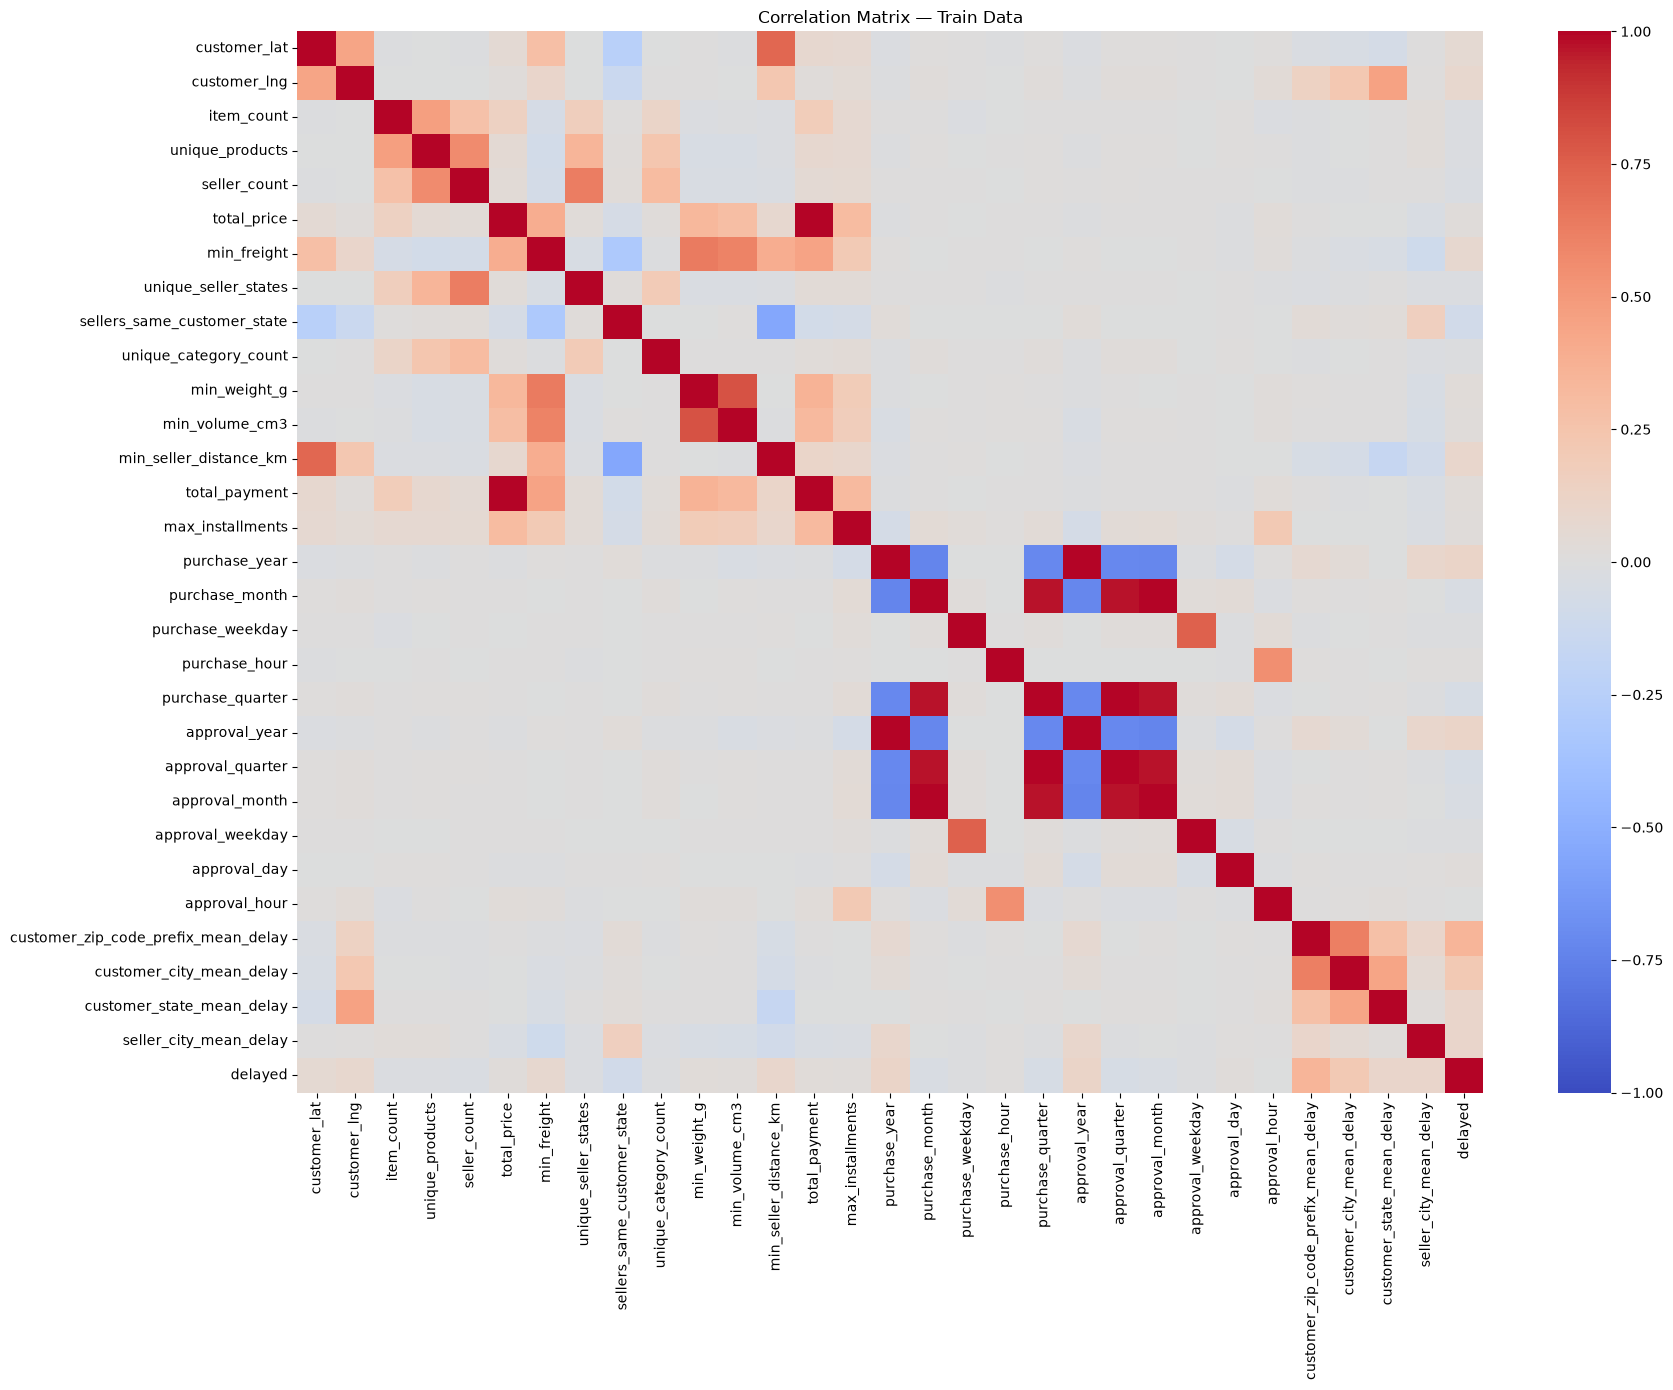

,feature,correlation,abs_correlation
0,customer_zip_code_prefix_mean_delay,0.347919,0.347919
1,customer_city_mean_delay,0.212503,0.212503
2,purchase_year,0.115500,0.115500
3,approval_year,0.114996,0.114996
4,customer_state_mean_delay,0.100342,0.100342
5,seller_city_mean_delay,0.098967,0.098967
6,sellers_same_customer_state,-0.089983,0.089983
7,min_seller_distance_km,0.086555,0.086555
8,customer_lng,0.082459,0.082459
9,min_freight,0.071296,0.071296


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CORRELATION MATRIX + DESCENDING CORRELATION TABLE
# ============================================================

# DataFrame للتدريب فقط بعد الـ preprocessing
corr_df = X_train.copy()

# إضافة الهدف
corr_df["delayed"] = y_train.values

# Correlation matrix
corr_matrix = corr_df.corr()

# ------------------------------------------------------------
# 1. Correlation Matrix
# ------------------------------------------------------------

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False
)

plt.title("Correlation Matrix — Train Data")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Descending correlation table with target
# ------------------------------------------------------------

target_corr = (
    corr_matrix["delayed"]
    .drop("delayed")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

correlation_table = pd.DataFrame({
    "feature": target_corr.index,
    "correlation": target_corr.values,
    "abs_correlation": target_corr.abs().values
})

correlation_table

## save

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TARGET DISTRIBUTION — TRAIN / VALIDATION / TEST
# ============================================================

datasets = {
    "Train": y_train,
    "Validation": y_validation,
    "Test": y_test
}

distribution = []

for name, y in datasets.items():
    counts = y.value_counts().sort_index()
    percentages = y.value_counts(normalize=True).sort_index() * 100

    distribution.append({
        "Dataset": name,
        "Not Delayed (0)": counts.get(0, 0),
        "Delayed (1)": counts.get(1, 0),
        "Not Delayed %": percentages.get(0, 0),
        "Delayed %": percentages.get(1, 0)
    })

target_distribution = pd.DataFrame(distribution)

print("TARGET DISTRIBUTION")
print("=" * 80)

display(
    target_distribution.style.format({
        "Not Delayed %": "{:.2f}%",
        "Delayed %": "{:.2f}%"
    })
)


TARGET DISTRIBUTION


,Dataset,Not Delayed (0),Delayed (1),Not Delayed %,Delayed %
0,Train,61431,6096,90.97%,9.03%
1,Validation,13697,773,94.66%,5.34%
2,Test,13514,957,93.39%,6.61%


In [19]:
from pathlib import Path
import json
import joblib
import pandas as pd

# ============================================================
# ARTIFACT DIRECTORY
# ============================================================

ARTIFACT_DIR = Path("../artifacts/feature_engineering")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. SAVE FINAL SCALED FEATURE TABLES
# ============================================================

feature_names = X_train.columns.tolist()

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_validation_scaled_df = pd.DataFrame(
    X_validation_scaled,
    columns=feature_names,
    index=X_validation.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)

X_train_scaled_df.to_csv(ARTIFACT_DIR / "train_features.csv", index=False)
X_validation_scaled_df.to_csv(ARTIFACT_DIR / "validation_features.csv", index=False)
X_test_scaled_df.to_csv(ARTIFACT_DIR / "test_features.csv", index=False)

# ============================================================
# 2. SAVE CLASSIFICATION TARGETS
# ============================================================

y_train.to_csv(ARTIFACT_DIR / "y_train.csv", index=False)
y_validation.to_csv(ARTIFACT_DIR / "y_validation.csv", index=False)
y_test.to_csv(ARTIFACT_DIR / "y_test.csv", index=False)

# ============================================================
# 3. SAVE REGRESSION TARGETS
# ============================================================

y_train_reg = train_clean["delay_days"].copy()
y_validation_reg = validation_clean["delay_days"].copy()
y_test_reg = test_clean["delay_days"].copy()

y_train_reg.to_csv(ARTIFACT_DIR / "y_train_reg.csv", index=False)
y_validation_reg.to_csv(ARTIFACT_DIR / "y_validation_reg.csv", index=False)
y_test_reg.to_csv(ARTIFACT_DIR / "y_test_reg.csv", index=False)

# ============================================================
# 4. SAVE FITTED SCALER
# ============================================================

joblib.dump(
    scaler,
    ARTIFACT_DIR / "scaler.joblib"
)

# ============================================================
# 5. SAVE MEAN DELAY ENCODING MAPPINGS
# ============================================================

joblib.dump(
    geo_mean_delay_maps,
    ARTIFACT_DIR / "geo_mean_delay_maps.joblib"
)

# ============================================================
# 6. SAVE GLOBAL FALLBACK
# ============================================================

joblib.dump(
    global_mean_delay,
    ARTIFACT_DIR / "global_mean_delay.joblib"
)

# ============================================================
# 7. SAVE FEATURE LIST
# ============================================================

with open(ARTIFACT_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_names, f, indent=2)

# ============================================================
# 8. SAVE PREPROCESSING CONFIGURATION
# ============================================================

preprocessing_config = {
    "classification_target": "delayed",
    "regression_target": "delay_days",
    "delay_days_cap": 70,
    "geographic_encoding": "mean_delay_encoding",
    "geographic_columns": GEO_COLS,
    "scaling": "MinMaxScaler",
    "scaling_range": [0, 1],
    "categorical_encoding": "none",
    "missing_value_strategy": "handled_before_final_feature_table"
}

with open(ARTIFACT_DIR / "preprocessing_config.json", "w", encoding="utf-8") as f:
    json.dump(preprocessing_config, f, indent=2)

# ============================================================
# 9. SUMMARY
# ============================================================

print("=" * 70)
print("FEATURE ENGINEERING ARTIFACTS SAVED")
print("=" * 70)

for path in sorted(ARTIFACT_DIR.iterdir()):
    print(path.name)

FEATURE ENGINEERING ARTIFACTS SAVED
feature_names.json
geo_mean_delay_maps.joblib
global_mean_delay.joblib
imputation_medians.joblib
preprocessing_config.json
replacement_values.joblib
scaler.joblib
test_features.csv
test_features_raw.csv
train_features.csv
train_features_raw.csv
validation_features.csv
validation_features_raw.csv
y_test.csv
y_test_reg.csv
y_train.csv
y_train_reg.csv
y_validation.csv
y_validation_reg.csv


In [20]:
from pathlib import Path
import joblib

ARTIFACT_DIR = Path("../artifacts/feature_engineering")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# SAVE TRAIN MEDIANS
# ============================================================

joblib.dump(
    train_medians.to_dict(),
    ARTIFACT_DIR / "imputation_medians.joblib"
)

# ============================================================
# SAVE REPLACEMENT VALUES
# ============================================================

replacement_values = {
    "item_count": 6,
    "unique_category_count": 5,
    "unique_seller_states": 2
}

joblib.dump(
    replacement_values,
    ARTIFACT_DIR / "replacement_values.joblib"
)

print("Saved:")
print(ARTIFACT_DIR / "imputation_medians.joblib")
print(ARTIFACT_DIR / "replacement_values.joblib")

Saved:
../artifacts/feature_engineering/imputation_medians.joblib
../artifacts/feature_engineering/replacement_values.joblib
